# 梯度下降优化算法
    w := w - η * dE/dw

epoch: 使用全部数据对模型完成一次完整训练的训练轮次

batch_size: 使用训练集中部分数据对模型进行参数更新，部分数据的批次数量

iteration: 使用一个batch数据对模型进行一次参数更新的过程

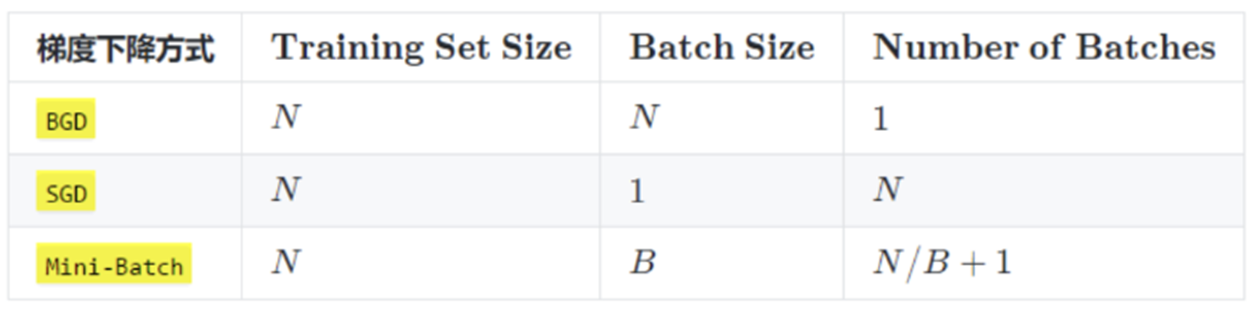

## 指数加权平均

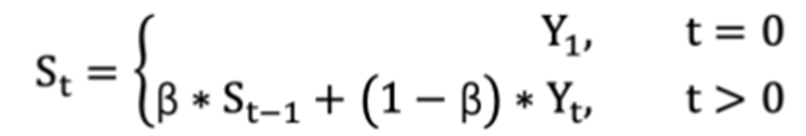

β: 调节权重系数，值越大平均数变化越平缓，一般默认0.9

## 动量算法Momentum(作为optim.SGD()里面的一个参数使用)
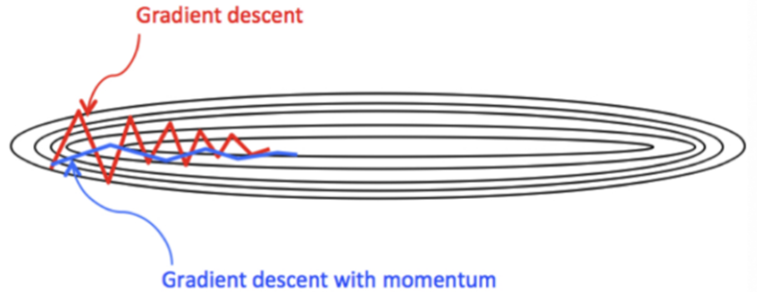
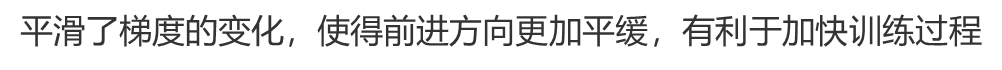


$ s_t = \beta * s_{t-1} + \eta * g_t $

$ w_t = w_{t-1} - s_t $

$s_t$: 历史梯度移动加权平均值

$g_t$: 当前时刻指数加权平均梯度

![image.png](attachment:3270aae7-13f2-4cba-90b9-7599f023eb59.png)

平滑了梯度的变化，使得前进方向更加平缓，有利于加快训练过程

## optim.AdaGrad()

假设第 $t$ 轮迭代中，参数 $\theta_i$ 的梯度为 $g_{t,i} = \nabla_{\theta_i} J(\theta_t)$。

1. **累积梯度平方和**：
$$
G_{t,i} = \sum_{\tau=1}^{t} g_{\tau,i}^2
$$
> 即从开始到当前时刻，该参数所有梯度平方的累加。

2. **参数更新**：
$$
\theta_{t+1,i} = \theta_{t,i} - \frac{\eta}{\sqrt{G_{t,i} + \epsilon}} \cdot g_{t,i}
$$

#### 符号说明
- $\eta$：全局学习率（通常设为 0.01）；
- $\epsilon$：极小常数（如 $10^{-8}$），防止分母为 0；
- $\theta_{t,i}$：第 $t$ 轮迭代中第 $i$ 个模型参数（如权重/偏置）；
- $g_{t,i}$：第 $t$ 轮迭代中第 $i$ 个参数的损失梯度；
- $G_{t,i}$：第 $i$ 个参数从第 1 轮到第 $t$ 轮的梯度平方累积和。

弊端：学习率过早、过量降低，模型后期学习率太小，难找到最优解

## optim.RMSprop()：稀疏、文本数据

稀疏数据里：动量会平滑掉稀疏信号，低频词更难学好

1.  **累积梯度平方的指数移动平均**

    $$
    v_t = \alpha v_{t-1} + (1 - \alpha) g_t^2
    $$

    - $g_t = \nabla_\theta J(\theta_{t-1})$：当前梯度。
    - $v_t$：当前时刻的梯度平方指数平均（二阶矩估计）。
    - $\alpha$：衰减率（通常取 0.99），控制历史信息的保留程度。
    - 初始 $v_0 = 0$。

2.  **参数更新**

    $$
    \theta_t = \theta_{t-1} - \frac{\eta}{\sqrt{v_t + \epsilon}}  g_t
    $$

    - $\eta$：全局学习率（通常设为 0.001）。
    - $\epsilon$：极小常数（如 $10^{-8}$），防止除零错误。

## Adam: Adaptive Moment Estimation = RMSprop + Momentum


设第 $t$ 轮迭代的梯度为 $g_t = \nabla_\theta J(\theta_{t-1})$。

1.  **更新有偏一阶矩估计（动量项）：**

    $$
    m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t
    $$

2.  **更新有偏二阶矩估计（自适应项）：**

    $$
    v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2
    $$

3.  **偏差修正（校正初始时刻估计偏向 0 的问题）：**

    $$
    \hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}
    $$

4.  **参数更新：**

    $$
    \theta_t = \theta_{t-1} - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon}  \hat{m}_t
    $$

其中：
- $\eta$：学习率（通常默认 0.001）。
- $\beta_1, \beta_2$：衰减率，控制一阶和二阶矩的指数衰减速率（通常 $\beta_1 = 0.9$, $\beta_2 = 0.999$）。
- $\epsilon$：极小常数（如 $10^{-8}$），防止除零错误。

In [7]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

w = torch.tensor([1.0], requires_grad= True, dtype= torch.float)
criterion = (w ** 2) / 2.0
optimizer = optim.Adam([w], lr= 0.01, betas= (0.9, 0.999))

optimizer.zero_grad()
criterion.sum().backward()
optimizer.step()

print(f'w:{w}, w.grad:{w.grad}')

criterion = (w ** 2) / 2.0
optimizer.zero_grad()
criterion.sum().backward()
optimizer.step()

print(f'w:{w}, w.grad:{w.grad}')

w:tensor([0.9900], requires_grad=True), w.grad:tensor([1.])
w:tensor([0.9800], requires_grad=True), w.grad:tensor([0.9900])


## 学习率衰减方法

### 等间隔衰减 : lr_scheduler.StepLR(optimizer, step_size, gamma)
    lr = lr * gamma

### 指定间隔衰减 : lr_scheduler.MultistepLR(optimizer, milestones, gamma)
    lr = lr * gamma

### 指数衰减 : lr_scheduler.ExponentialLR(optimizer, gamma)
    lr = lr * gamma ** epoch

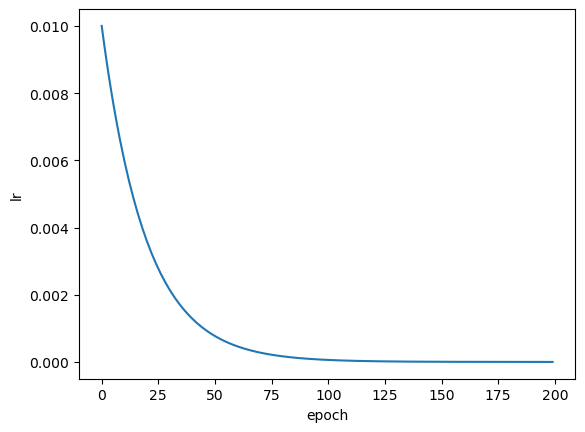

In [8]:
epochs, lr, iteration = 200, 0.1, 10
y_true = torch.tensor([0])
x = torch.tensor([1.0], dtype= torch.float)
w = torch.tensor([1.0], requires_grad= True, dtype= torch.float)
optimizer = optim.SGD([w], lr= 0.01, momentum= 0.9)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma= 0.95)
lr_list, epoch_list = [], []

for epoch in range(epochs):
    epoch_list.append(epoch)
    lr_list.append(scheduler.get_last_lr())

    for batch in range(iteration):
        y_pred = w * x
        loss = (y_pred - y_true) ** 2
        optimizer.zero_grad()
        loss.sum().backward()
        optimizer.step()

    scheduler.step()

# print(f'lr_list:{lr_list}')

plt.plot(epoch_list, lr_list)
plt.xlabel('epoch')
plt.ylabel('lr')
plt.show()

# 正则化优化方法

## Dropout正则化

在神经网络模型参数较多饭数据量不足时，容易过拟合

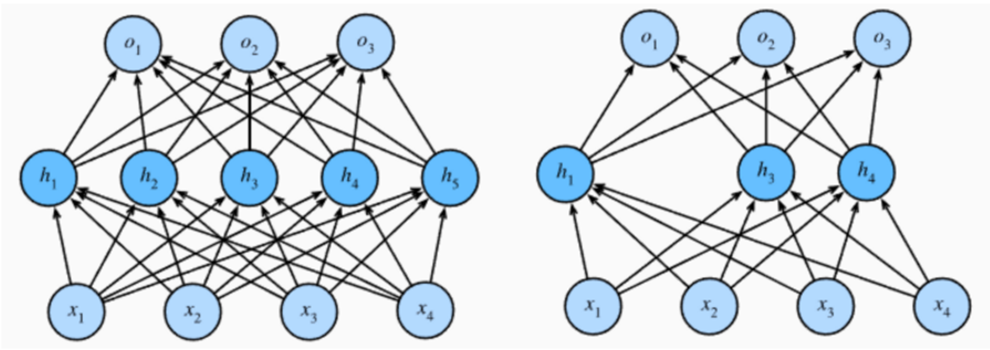

- 让神经元以超参数p的概率停止工作或者激活被置为0,未被置为0的进行缩放，缩放比例为1/(1-p)
- **缩放比例的来源：保证与测试阶段的期望输出一致**

- 训练过程可以认为是对完整的神经网络的一些子集进行训练，每次基于输入数据只更新子网络的参数

- 在测试过程中，随机失活不起作用
    - **model.eval() : 测试模式**
    - **model.train() : 训练模式**
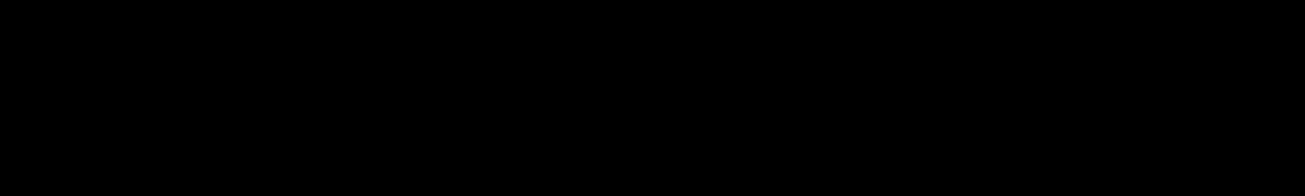

In [9]:
import torch.nn as nn
t1 = torch.randint(0, 10, size = (1, 4)).float()
print(f'输入t1:{t1}')

# 进行加权求和和激活函数
linear1 = nn.Linear(4, 5)
l1 = linear1(t1)
print(f'加权求和l1:{l1}')
h1 = torch.relu(l1)
print(f'激活后h1:{h1}')

# 进行dropout
dropout = nn.Dropout(p= 0.3)
d1 = dropout(h1)
print(f'正则化后d1:{d1}')

输入t1:tensor([[4., 5., 8., 1.]])
加权求和l1:tensor([[ 2.1474, -4.1392,  4.1536, -2.9103, -3.2628]],
       grad_fn=<AddmmBackward0>)
激活后h1:tensor([[2.1474, 0.0000, 4.1536, 0.0000, 0.0000]], grad_fn=<ReluBackward0>)
正则化后d1:tensor([[3.0677, 0.0000, 5.9337, 0.0000, 0.0000]], grad_fn=<MulBackward0>)


## 批量归一化 Batch Normalization

先对数据标准化(丢失一些信息),再对数据重构(缩放+平移：找补一些信息)

- **作用**：减少内部协方差偏移，让数据更集中，将激活值约束在敏感区域，加速训练

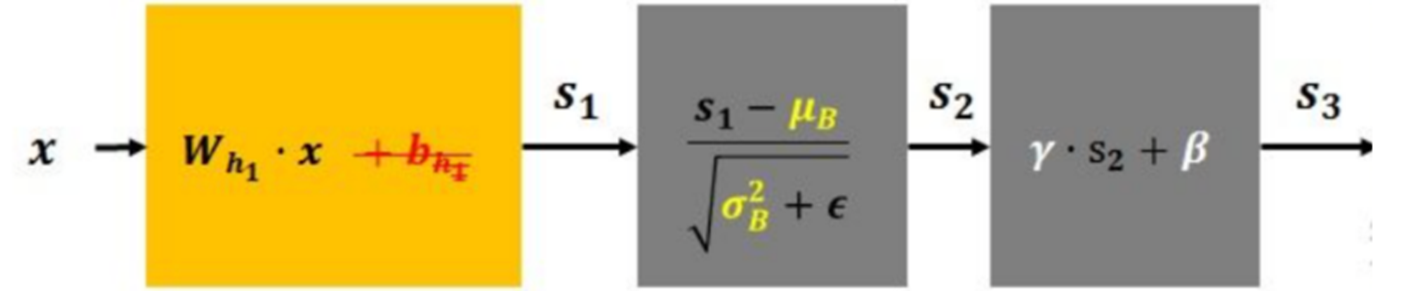

- $ \lambda 和 \beta 是可学习的参数， \epsilon是小参数，防止除以0$

$$f(x) = \lambda \cdot \frac{x - \mathrm{E}(x)}{\sqrt{\mathrm{Var}(x) + \epsilon}} + \beta$$

In [10]:
input_2d = torch.randn(size = (1, 2, 3, 4)) # 一个照片，两个通道，3行4列
print(f'输入input_2d:{input_2d}')

# 前四个参数：通道数，保护分母小参数，动量法，是否开启γ和β两个可学习参数
# 最后一个参数：是否区分测试和训练模式
# 训练时：用当前批次的均值 / 方差归一化，同时更新全局运行均值 / 方差；
# 测试时：固定用全局运行均值 / 方差归一化（避免批次波动影响结果）
bn2d = nn.BatchNorm2d(num_features = 2, eps = 1e-5, momentum = 0.1, affine = True, track_running_stats = True)
output_2d = bn2d(input_2d)
print(f'输出output_2d:{output_2d}')

input_1d = torch.randn(size = (2, 2))
print(f'输入input_1d:{input_1d}')

# 先创建线性层
linear1 = nn.Linear(2, 4)
l1 = linear1(input_1d)
print(f'l1_shape:{l1.shape}')

bn1d = nn.BatchNorm1d(num_features = 4, eps = 1e-5, momentum = 0.1, affine = True, track_running_stats = True)
output_1d = bn1d(l1)
print(f'输出output_1d:{output_1d}')

输入input_2d:tensor([[[[ 0.0199, -1.1521,  1.9517,  1.4677],
          [ 1.0297,  1.3556, -1.3543,  1.5093],
          [ 0.6278, -0.5101, -2.8603, -1.6851]],

         [[ 0.0149,  0.9743,  0.1340,  0.7350],
          [ 0.1972, -0.0140, -0.5802, -0.9466],
          [ 1.7637,  0.5415,  0.2048, -0.6253]]]])
输出output_2d:tensor([[[[-0.0091, -0.8059,  1.3042,  0.9752],
          [ 0.6774,  0.8990, -0.9434,  1.0035],
          [ 0.4042, -0.3694, -1.9672, -1.1683]],

         [[-0.2588,  1.0829, -0.0922,  0.7482],
          [-0.0039, -0.2992, -1.0909, -1.6033],
          [ 2.1867,  0.4776,  0.0068, -1.1540]]]],
       grad_fn=<NativeBatchNormBackward0>)
输入input_1d:tensor([[ 1.6407, -0.1611],
        [ 0.4322, -0.1993]])
l1_shape:torch.Size([2, 4])
输出output_1d:tensor([[ 1.0000,  0.9530,  0.9999,  0.9997],
        [-1.0000, -0.9530, -0.9999, -0.9997]],
       grad_fn=<NativeBatchNormBackward0>)
